In [1]:
import os
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split
)


In [2]:
# ============================================================
# 1. Reproducibility and device configuration
# ============================================================
def seed_everything(seed=42):
    """
    Set random seeds for reproducible model training.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception as error:
        print(
            "Warning: deterministic algorithms "
            f"were not fully enabled: {error}"
        )


seed_everything(42)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)


Using device: cpu


In [3]:
# ============================================================
# 2. Define the multilayer perceptron model
# ============================================================
class MLPRegressor(nn.Module):
    """
    Multilayer perceptron for overpotential regression.
    """

    def __init__(
        self,
        input_dim,
        hidden_dims=None,
        dropout=0.1
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [256, 128, 64]

        feature_layers = []
        dimensions = [input_dim] + hidden_dims

        for i in range(len(hidden_dims)):
            feature_layers.append(
                nn.Linear(
                    dimensions[i],
                    dimensions[i + 1]
                )
            )
            feature_layers.append(
                nn.BatchNorm1d(
                    dimensions[i + 1]
                )
            )
            feature_layers.append(
                nn.ReLU()
            )
            feature_layers.append(
                nn.Dropout(dropout)
            )

        self.feature_extractor = nn.Sequential(
            *feature_layers
        )

        self.regressor = nn.Linear(
            hidden_dims[-1],
            1
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.regressor(x)

        return x


In [4]:
# ============================================================
# 3. Load the five-metal target-domain dataset
# ============================================================
target_data_path = "data/5metal_data_features.csv"

df_5m = pd.read_csv(target_data_path)

y_5m = df_5m["overpotential"].values

X_5m_df = df_5m.drop(
    columns=[
        "compound",
        "overpotential",
        "composition_key"
    ]
)

X_5m = X_5m_df.values

print(
    "Complete five-metal dataset:",
    X_5m.shape,
    y_5m.shape
)


# ============================================================
# 4. Split the five-metal dataset
# ============================================================

# Divide the overpotential values into five quantile-based
# bins for stratified splitting
y_bins = pd.qcut(
    y_5m,
    q=5,
    labels=False,
    duplicates="drop"
)

# Retain 30% of the five-metal samples for model development
# and use 70% as the independent test set
(
    X_5m_trainval_raw,
    X_5m_test_raw,
    y_5m_trainval,
    y_5m_test,
    y_bins_trainval,
    y_bins_test
) = train_test_split(
    X_5m,
    y_5m,
    y_bins,
    test_size=0.7,
    random_state=2027,
    stratify=y_bins
)

# Preserve the original internal split because it determines
# the sample order in the subsequently combined dataset
(
    X_5m_train_raw,
    X_5m_val_raw,
    y_5m_train,
    y_5m_val
) = train_test_split(
    X_5m_trainval_raw,
    y_5m_trainval,
    test_size=0.2,
    random_state=42,
    stratify=y_bins_trainval
)

print(
    "Five-metal training subset:",
    X_5m_train_raw.shape,
    y_5m_train.shape
)

print(
    "Five-metal validation subset:",
    X_5m_val_raw.shape,
    y_5m_val.shape
)

print(
    "Five-metal independent test set:",
    X_5m_test_raw.shape,
    y_5m_test.shape
)

Complete five-metal dataset: (246, 25) (246,)
Five-metal training subset: (58, 25) (58,)
Five-metal validation subset: (15, 25) (15,)
Five-metal independent test set: (173, 25) (173,)


In [5]:
# ============================================================
# 5. Load the source-domain scaler
# ============================================================
pretrained_scaler_path = (
    "model/scaler_schemeD_pretrained.pkl"
)

if not os.path.exists(pretrained_scaler_path):
    raise FileNotFoundError(
        "Pretrained scaler not found: "
        f"{pretrained_scaler_path}"
    )

scaler_D = joblib.load(
    pretrained_scaler_path
)

# Apply the source-domain scaler without refitting it
X_train_D = scaler_D.transform(
    X_5m_train_raw
)

X_val_D = scaler_D.transform(
    X_5m_val_raw
)

X_test_D = scaler_D.transform(
    X_5m_test_raw
)

X_trainval_D = scaler_D.transform(
    X_5m_trainval_raw
)

In [6]:
# ============================================================
# 6. Create fine-tuning data loaders
# ============================================================
train_loader_D = DataLoader(
    TensorDataset(
        torch.tensor(
            X_train_D,
            dtype=torch.float32
        ),
        torch.tensor(
            y_5m_train,
            dtype=torch.float32
        ).view(-1, 1)
    ),
    batch_size=32,
    shuffle=True
)

val_loader_D = DataLoader(
    TensorDataset(
        torch.tensor(
            X_val_D,
            dtype=torch.float32
        ),
        torch.tensor(
            y_5m_val,
            dtype=torch.float32
        ).view(-1, 1)
    ),
    batch_size=32,
    shuffle=False
)

test_loader_D = DataLoader(
    TensorDataset(
        torch.tensor(
            X_test_D,
            dtype=torch.float32
        ),
        torch.tensor(
            y_5m_test,
            dtype=torch.float32
        ).view(-1, 1)
    ),
    batch_size=32,
    shuffle=False
)

# Recombine the training and validation subsets while
# preserving the sample order used in the original workflow
trainval_dataset_D = torch.utils.data.ConcatDataset(
    [
        train_loader_D.dataset,
        val_loader_D.dataset
    ]
)

trainval_loader_D = DataLoader(
    trainval_dataset_D,
    batch_size=train_loader_D.batch_size,
    shuffle=True
)

trainval_eval_loader_D = DataLoader(
    trainval_dataset_D,
    batch_size=train_loader_D.batch_size,
    shuffle=False
)

In [7]:
# ============================================================
# 7. Define the fixed-epoch training function
# ============================================================
def train_model_fixed_epochs(
    model,
    train_loader,
    epochs=500,
    lr=5e-5,
    weight_decay=5e-4,
    device=None
):
    """
    Train all model parameters for a fixed number of epochs.
    """
    if device is None:
        device = torch.device(
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = nn.MSELoss()
    train_losses = []

    for epoch in range(epochs):
        model.train()

        total_train_loss = 0.0
        n_train = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            loss.backward()
            optimizer.step()

            batch_size = X_batch.size(0)

            total_train_loss += (
                loss.item() * batch_size
            )

            n_train += batch_size

        epoch_train_loss = (
            total_train_loss / n_train
        )

        train_losses.append(
            epoch_train_loss
        )

        if (
            epoch % 20 == 0
            or epoch == epochs - 1
        ):
            print(
                f"Epoch {epoch:03d}: "
                f"Train Loss={epoch_train_loss:.6f}"
            )

    return model, train_losses

In [8]:
# ============================================================
# 8. Load the pretrained model and perform full fine-tuning
# ============================================================
pretrained_model_path = (
    "model/mlp_schemeD_pretrained.pth"
)

if not os.path.exists(pretrained_model_path):
    raise FileNotFoundError(
        "Pretrained model not found: "
        f"{pretrained_model_path}"
    )

seed_everything(42)

model_D_final = MLPRegressor(
    input_dim=X_train_D.shape[1],
    hidden_dims=[256, 128, 64],
    dropout=0.02
)

pretrained_state_dict = torch.load(
    pretrained_model_path,
    map_location="cpu"
)

model_D_final.load_state_dict(
    pretrained_state_dict
)

model_D_final = model_D_final.to(device)

model_D_final, fine_tuning_losses = (
    train_model_fixed_epochs(
        model=model_D_final,
        train_loader=trainval_loader_D,
        epochs=250,
        lr=2e-5,
        weight_decay=1.5e-2,
        device=device
    )
)

Epoch 000: Train Loss=0.145103
Epoch 020: Train Loss=0.066033
Epoch 040: Train Loss=0.038645
Epoch 060: Train Loss=0.036625
Epoch 080: Train Loss=0.023618
Epoch 100: Train Loss=0.019312
Epoch 120: Train Loss=0.019499
Epoch 140: Train Loss=0.013915
Epoch 160: Train Loss=0.018535
Epoch 180: Train Loss=0.012470
Epoch 200: Train Loss=0.011889
Epoch 220: Train Loss=0.035165
Epoch 240: Train Loss=0.023330
Epoch 249: Train Loss=0.017842


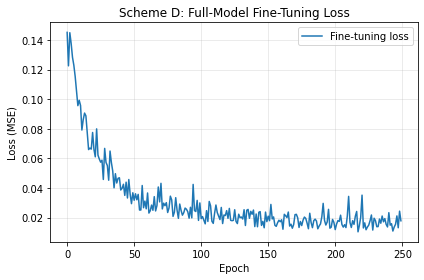

In [9]:
# ============================================================
# 9. Plot the fine-tuning loss
# ============================================================
plt.figure(figsize=(6, 4))

plt.plot(
    fine_tuning_losses,
    label="Fine-tuning loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Scheme D: Full-Model Fine-Tuning Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
# ============================================================
# 10. Define prediction and evaluation functions
# ============================================================
def mean_absolute_percentage_error(
    y_true,
    y_pred
):
    """
    Calculate the mean absolute percentage error.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    nonzero_mask = y_true != 0

    if nonzero_mask.sum() == 0:
        return np.nan

    return (
        np.mean(
            np.abs(
                (
                    y_true[nonzero_mask]
                    - y_pred[nonzero_mask]
                )
                / y_true[nonzero_mask]
            )
        )
        * 100
    )


def compute_metrics(y_true, y_pred):
    """
    Calculate regression performance metrics.
    """
    mse = mean_squared_error(
        y_true,
        y_pred
    )

    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(mse),
        "MSE": mse,
        "R2": r2_score(
            y_true,
            y_pred
        ),
        "MAPE": mean_absolute_percentage_error(
            y_true,
            y_pred
        )
    }


def predict(loader, model, device):
    """
    Generate model predictions for a data loader.
    """
    model.eval()

    predictions = []
    true_values = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            batch_predictions = (
                model(X_batch)
                .cpu()
                .numpy()
                .flatten()
            )

            batch_true_values = (
                y_batch
                .cpu()
                .numpy()
                .flatten()
            )

            predictions.extend(
                batch_predictions
            )

            true_values.extend(
                batch_true_values
            )

    return (
        np.asarray(true_values),
        np.asarray(predictions)
    )

In [11]:
# ============================================================
# 11. Evaluate the fine-tuned Scheme D model
# ============================================================
(
    y_trainval_true_D,
    y_trainval_pred_D
) = predict(
    trainval_eval_loader_D,
    model_D_final,
    device
)

(
    y_test_true_D,
    y_test_pred_D
) = predict(
    test_loader_D,
    model_D_final,
    device
)

trainval_metrics_D = compute_metrics(
    y_trainval_true_D,
    y_trainval_pred_D
)

test_metrics_D = compute_metrics(
    y_test_true_D,
    y_test_pred_D
)

print(
    "=== Scheme D: Fine-Tuning Metrics ==="
)

for metric_name, metric_value in (
    trainval_metrics_D.items()
):
    print(
        f"{metric_name}: {metric_value:.6f}"
    )

print(
    "\n=== Scheme D: Independent Test Metrics ==="
)

for metric_name, metric_value in (
    test_metrics_D.items()
):
    print(
        f"{metric_name}: {metric_value:.6f}"
    )

=== Scheme D: Fine-Tuning Metrics ===
MAE: 0.051069
RMSE: 0.064845
MSE: 0.004205
R2: 0.953840
MAPE: 4.192682

=== Scheme D: Independent Test Metrics ===
MAE: 0.107576
RMSE: 0.134842
MSE: 0.018182
R2: 0.816281
MAPE: 9.492633


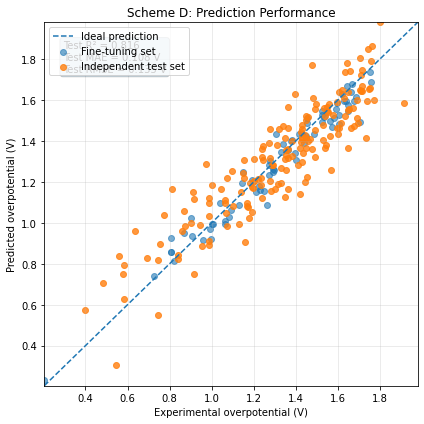

In [12]:
# ============================================================
# 13. Plot actual versus predicted overpotentials
# ============================================================
plt.figure(figsize=(6, 6))

plt.scatter(
    y_trainval_true_D,
    y_trainval_pred_D,
    alpha=0.6,
    label="Fine-tuning set"
)

plt.scatter(
    y_test_true_D,
    y_test_pred_D,
    alpha=0.8,
    label="Independent test set"
)

all_true_values = np.concatenate(
    [
        np.ravel(y_trainval_true_D),
        np.ravel(y_test_true_D)
    ]
)

all_predicted_values = np.concatenate(
    [
        np.ravel(y_trainval_pred_D),
        np.ravel(y_test_pred_D)
    ]
)

minimum_value = min(
    all_true_values.min(),
    all_predicted_values.min()
)

maximum_value = max(
    all_true_values.max(),
    all_predicted_values.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=1.5,
    label="Ideal prediction"
)

plt.xlabel("Experimental overpotential (V)")
plt.ylabel("Predicted overpotential (V)")
plt.title("Scheme D: Prediction Performance")

plt.xlim(
    minimum_value,
    maximum_value
)

plt.ylim(
    minimum_value,
    maximum_value
)

metric_text = (
    f"Test R² = {test_metrics_D['R2']:.3f}\n"
    f"Test MAE = {test_metrics_D['MAE']:.3f} V\n"
    f"Test RMSE = {test_metrics_D['RMSE']:.3f} V"
)

plt.text(
    0.05,
    0.95,
    metric_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox={
        "boxstyle": "round",
        "alpha": 0.2
    }
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 14. Save Scheme D predictions
# ============================================================
os.makedirs(
    "results",
    exist_ok=True
)

schemeD_trainval_df = pd.DataFrame(
    {
        "Actual_Overpotential": np.ravel(
            y_trainval_true_D
        ),
        "Predicted_Overpotential": np.ravel(
            y_trainval_pred_D
        ),
        "Absolute_Error": np.abs(
            np.ravel(y_trainval_true_D)
            - np.ravel(y_trainval_pred_D)
        )
    }
)

schemeD_test_df = pd.DataFrame(
    {
        "Actual_Overpotential": np.ravel(
            y_test_true_D
        ),
        "Predicted_Overpotential": np.ravel(
            y_test_pred_D
        ),
        "Absolute_Error": np.abs(
            np.ravel(y_test_true_D)
            - np.ravel(y_test_pred_D)
        )
    }
)

schemeD_trainval_path = (
    "results/schemeD_finetune_predictions.csv"
)

schemeD_test_path = (
    "results/schemeD_test_predictions.csv"
)

schemeD_trainval_df.to_csv(
    schemeD_trainval_path,
    index=False
)

schemeD_test_df.to_csv(
    schemeD_test_path,
    index=False
)

print(
    "Scheme D fine-tuning predictions saved to:",
    schemeD_trainval_path
)

print(
    "Scheme D test predictions saved to:",
    schemeD_test_path
)

Scheme D fine-tuning predictions saved to: results/schemeD_finetune_predictions.csv
Scheme D test predictions saved to: results/schemeD_test_predictions.csv


In [14]:
# ============================================================
# 15. Save the final fine-tuned model
# ============================================================
os.makedirs(
    "model",
    exist_ok=True
)

fine_tuned_model_path = (
    "model/mlp_schemeD_final_finetuned.pth"
)

torch.save(
    model_D_final.state_dict(),
    fine_tuned_model_path
)

print(
    "Scheme D fine-tuned model saved to:",
    fine_tuned_model_path
)

Scheme D fine-tuned model saved to: model/mlp_schemeD_final_finetuned.pth
